# Multiple files with `pandas`

In [1]:
import numpy as np
import pandas as pd
import matplotlib

## Merge Practice


In [2]:
a_df = pd.DataFrame({
    'Country': ['Germany', 'France', 'Belgium', 'Finland'],
    'Population (M)': [82.8, 67.2, 11.4, 5.5],
    'Capital': ['Berlin', 'Paris', 'Brussels', 'Helsinki']
})
a_df

,Country,Population (M),Capital
0,Germany,82.8,Berlin
1,France,67.2,Paris
2,Belgium,11.4,Brussels
3,Finland,5.5,Helsinki


In [3]:
b_df = pd.DataFrame({
    'Country': ['Germany', 'France', 'Belgium', 'Canada'],
    'HDI': [0.936, 0.901, 0.916, 0.926]
})
b_df

,Country,HDI
0,Germany,0.936
1,France,0.901
2,Belgium,0.916
3,Canada,0.926


### Inner Merge Practice

In [4]:
inner_merged_df = a_df.merge(b_df, on='Country')
inner_merged_df

,Country,Population (M),Capital,HDI
0,Germany,82.8,Berlin,0.936
1,France,67.2,Paris,0.901
2,Belgium,11.4,Brussels,0.916


### Left Merge Practice

In [5]:
left_merged_df = a_df.merge(b_df, on='Country', how='left')
left_merged_df

,Country,Population (M),Capital,HDI
0,Germany,82.8,Berlin,0.936
1,France,67.2,Paris,0.901
2,Belgium,11.4,Brussels,0.916
3,Finland,5.5,Helsinki,NaN


### Left Merge Practice


In [6]:
from nbresult import ChallengeResult

result = ChallengeResult('left_merge',
    left_merged_shape=left_merged_df.shape,
    left_merged_nulls=sum(left_merged_df.isnull().sum())
)
result.write()

print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/fatimah/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
rootdir: /home/fatimah/code/Fatima-23s/02-Data-Toolkit/01-Data-Analysis/data-multiple-files-with-pandas
configfile: pytest.ini
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 2 items

test_left_merge.py::TestLeftMerge::test_left_merged_df_shape PASSED      [ 50%]
test_left_merge.py::TestLeftMerge::test_left_merged_nulls PASSED         [100%]

============================== 2 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/left_merge.pickle

git commit -m 'Completed left_merge step'

git push origin master



In [7]:
### Right Merge Practice

In [8]:
right_merged_df = a_df.merge(b_df, on='Country', how='right')
right_merged_df

,Country,Population (M),Capital,HDI
0,Germany,82.8,Berlin,0.936
1,France,67.2,Paris,0.901
2,Belgium,11.4,Brussels,0.916
3,Canada,NaN,NaN,0.926


### Outer Merge Practice


In [9]:
outer_merged_df = a_df.merge(b_df, on='Country', how='outer')
outer_merged_df

,Country,Population (M),Capital,HDI
0,Belgium,11.4,Brussels,0.916
1,Canada,NaN,NaN,0.926
2,Finland,5.5,Helsinki,NaN
3,France,67.2,Paris,0.901
4,Germany,82.8,Berlin,0.936


In [10]:
from nbresult import ChallengeResult

result = ChallengeResult('outer_merge',
    outer_merged_shape=outer_merged_df.shape,
    outer_merged_nulls=sum(outer_merged_df.isnull().sum())
)
result.write()

print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/fatimah/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
rootdir: /home/fatimah/code/Fatima-23s/02-Data-Toolkit/01-Data-Analysis/data-multiple-files-with-pandas
configfile: pytest.ini
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 2 items

test_outer_merge.py::TestOuterMerge::test_outer_merged_df_shape PASSED   [ 50%]
test_outer_merge.py::TestOuterMerge::test_outer_merged_nulls PASSED      [100%]

============================== 2 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/outer_merge.pickle

git commit -m 'Completed outer_merge step'

git push origin master



## Join Practice

In [11]:
aa_df = a_df.set_index("Country")
aa_df

,Population (M),Capital
Country,,
Germany,82.8,Berlin
France,67.2,Paris
Belgium,11.4,Brussels
Finland,5.5,Helsinki


In [12]:
bb_df = b_df.set_index("Country")
bb_df

,HDI
Country,
Germany,0.936
France,0.901
Belgium,0.916
Canada,0.926


In [13]:
aa_df.join(bb_df)

,Population (M),Capital,HDI
Country,,,
Germany,82.8,Berlin,0.936
France,67.2,Paris,0.901
Belgium,11.4,Brussels,0.916
Finland,5.5,Helsinki,NaN


In [14]:
aa_df.join(bb_df, how='inner')

,Population (M),Capital,HDI
Country,,,
Germany,82.8,Berlin,0.936
France,67.2,Paris,0.901
Belgium,11.4,Brussels,0.916


In [15]:
aa_df.join(bb_df, how='right')

,Population (M),Capital,HDI
Country,,,
Germany,82.8,Berlin,0.936
France,67.2,Paris,0.901
Belgium,11.4,Brussels,0.916
Canada,NaN,NaN,0.926


In [16]:
aa_df.join(bb_df, how='outer')

,Population (M),Capital,HDI
Country,,,
Belgium,11.4,Brussels,0.916
Canada,NaN,NaN,0.926
Finland,5.5,Helsinki,NaN
France,67.2,Paris,0.901
Germany,82.8,Berlin,0.936


## Concat Practice

In [17]:
concat_df = pd.concat([a_df, b_df], axis="index", sort=False)
concat_df

,Country,Population (M),Capital,HDI
0,Germany,82.8,Berlin,NaN
1,France,67.2,Paris,NaN
2,Belgium,11.4,Brussels,NaN
3,Finland,5.5,Helsinki,NaN
0,Germany,NaN,NaN,0.936
1,France,NaN,NaN,0.901
2,Belgium,NaN,NaN,0.916
3,Canada,NaN,NaN,0.926


## Olympic Sports and Medals, 1896-2014

In [18]:
countries_df = pd.read_csv('dictionary.csv')
summer_df = pd.read_csv('summer.csv')
winter_df = pd.read_csv('winter.csv')

### Combining The Data

In [19]:
summer_countries_df = countries_df.merge(summer_df, left_on='Code', right_on='Country')
summer_countries_df['Season'] = 'Summer'
summer_countries_df

,Country_x,Code,Population,GDP per Capita,Year,City,Sport,Discipline,Athlete,Country_y,Gender,Event,Medal,Season
0,Afghanistan,AFG,32526562.0,594.323081,2008,Beijing,Taekwondo,Taekwondo,"NIKPAI, Rohullah",AFG,Men,- 58 KG,Bronze,Summer
1,Afghanistan,AFG,32526562.0,594.323081,2012,London,Taekwondo,Taekwondo,"NIKPAI, Rohullah",AFG,Men,58 - 68 KG,Bronze,Summer
2,Algeria,ALG,39666519.0,4206.031232,1984,Los Angeles,Boxing,Boxing,"ZAOUI, Mohamed",ALG,Men,71-75KG,Bronze,Summer
3,Algeria,ALG,39666519.0,4206.031232,1984,Los Angeles,Boxing,Boxing,"MOUSSA, Mustapha",ALG,Men,75 - 81KG (Light-Heavyweight),Bronze,Summer
4,Algeria,ALG,39666519.0,4206.031232,1992,Barcelona,Athletics,Athletics,"BOULMERKA, Hassiba",ALG,Women,1500M,Gold,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25737,Zimbabwe,ZIM,15602751.0,924.143819,2004,Athens,Aquatics,Swimming,"COVENTRY, Kirsty",ZIM,Women,200M Individual Medley,Bronze,Summer
25738,Zimbabwe,ZIM,15602751.0,924.143819,2008,Beijing,Aquatics,Swimming,"COVENTRY, Kirsty",ZIM,Women,100M Backstroke,Silver,Summer
25739,Zimbabwe,ZIM,15602751.0,924.143819,2008,Beijing,Aquatics,Swimming,"COVENTRY, Kirsty",ZIM,Women,200M Backstroke,Gold,Summer
25740,Zimbabwe,ZIM,15602751.0,924.143819,2008,Beijing,Aquatics,Swimming,"COVENTRY, Kirsty",ZIM,Women,200M Individual Medley,Silver,Summer


In [20]:
winter_countries_df = countries_df.merge(winter_df, left_on='Code', right_on='Country')
winter_countries_df['Season'] = 'Winter'
winter_countries_df

,Country_x,Code,Population,GDP per Capita,Year,City,Sport,Discipline,Athlete,Country_y,Gender,Event,Medal,Season
0,Australia,AUS,23781169.0,56310.962993,1994,Lillehammer,Skating,Short Track Speed Skating,"BRADBURY, Steven",AUS,Men,5000M Relay,Bronze,Winter
1,Australia,AUS,23781169.0,56310.962993,1994,Lillehammer,Skating,Short Track Speed Skating,"HANSEN, Kieran",AUS,Men,5000M Relay,Bronze,Winter
2,Australia,AUS,23781169.0,56310.962993,1994,Lillehammer,Skating,Short Track Speed Skating,"MURTHA, Andrew",AUS,Men,5000M Relay,Bronze,Winter
3,Australia,AUS,23781169.0,56310.962993,1994,Lillehammer,Skating,Short Track Speed Skating,"NIZIELSKI, Richard",AUS,Men,5000M Relay,Bronze,Winter
4,Australia,AUS,23781169.0,56310.962993,1998,Nagano,Skiing,Alpine Skiing,"STEGGALL, Zali",AUS,Women,Slalom,Bronze,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4821,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"DEIBOLD, Alex",USA,Men,Snowboard Cross,Bronze,Winter
4822,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"CLARK, Kelly",USA,Women,Half-Pipe,Bronze,Winter
4823,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"FARRINGTON, Kaitlyn",USA,Women,Half-Pipe,Gold,Winter
4824,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"ANDERSON, Jamie",USA,Women,Slopestyle,Gold,Winter


In [21]:
all_df = pd.concat([summer_countries_df, winter_countries_df], ignore_index=True)
all_df

,Country_x,Code,Population,GDP per Capita,Year,City,Sport,Discipline,Athlete,Country_y,Gender,Event,Medal,Season
0,Afghanistan,AFG,32526562.0,594.323081,2008,Beijing,Taekwondo,Taekwondo,"NIKPAI, Rohullah",AFG,Men,- 58 KG,Bronze,Summer
1,Afghanistan,AFG,32526562.0,594.323081,2012,London,Taekwondo,Taekwondo,"NIKPAI, Rohullah",AFG,Men,58 - 68 KG,Bronze,Summer
2,Algeria,ALG,39666519.0,4206.031232,1984,Los Angeles,Boxing,Boxing,"ZAOUI, Mohamed",ALG,Men,71-75KG,Bronze,Summer
3,Algeria,ALG,39666519.0,4206.031232,1984,Los Angeles,Boxing,Boxing,"MOUSSA, Mustapha",ALG,Men,75 - 81KG (Light-Heavyweight),Bronze,Summer
4,Algeria,ALG,39666519.0,4206.031232,1992,Barcelona,Athletics,Athletics,"BOULMERKA, Hassiba",ALG,Women,1500M,Gold,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30563,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"DEIBOLD, Alex",USA,Men,Snowboard Cross,Bronze,Winter
30564,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"CLARK, Kelly",USA,Women,Half-Pipe,Bronze,Winter
30565,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"FARRINGTON, Kaitlyn",USA,Women,Half-Pipe,Gold,Winter
30566,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"ANDERSON, Jamie",USA,Women,Slopestyle,Gold,Winter


In [22]:
countries_df = pd.read_csv('dictionary.csv')
summer_df = pd.read_csv('summer.csv')
winter_df = pd.read_csv('winter.csv')

In [23]:
### Combining The Data

In [24]:
summer_countries_df = countries_df.merge(summer_df, left_on='Code', right_on='Country')
summer_countries_df['Season'] = 'Summer'
summer_countries_df

,Country_x,Code,Population,GDP per Capita,Year,City,Sport,Discipline,Athlete,Country_y,Gender,Event,Medal,Season
0,Afghanistan,AFG,32526562.0,594.323081,2008,Beijing,Taekwondo,Taekwondo,"NIKPAI, Rohullah",AFG,Men,- 58 KG,Bronze,Summer
1,Afghanistan,AFG,32526562.0,594.323081,2012,London,Taekwondo,Taekwondo,"NIKPAI, Rohullah",AFG,Men,58 - 68 KG,Bronze,Summer
2,Algeria,ALG,39666519.0,4206.031232,1984,Los Angeles,Boxing,Boxing,"ZAOUI, Mohamed",ALG,Men,71-75KG,Bronze,Summer
3,Algeria,ALG,39666519.0,4206.031232,1984,Los Angeles,Boxing,Boxing,"MOUSSA, Mustapha",ALG,Men,75 - 81KG (Light-Heavyweight),Bronze,Summer
4,Algeria,ALG,39666519.0,4206.031232,1992,Barcelona,Athletics,Athletics,"BOULMERKA, Hassiba",ALG,Women,1500M,Gold,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25737,Zimbabwe,ZIM,15602751.0,924.143819,2004,Athens,Aquatics,Swimming,"COVENTRY, Kirsty",ZIM,Women,200M Individual Medley,Bronze,Summer
25738,Zimbabwe,ZIM,15602751.0,924.143819,2008,Beijing,Aquatics,Swimming,"COVENTRY, Kirsty",ZIM,Women,100M Backstroke,Silver,Summer
25739,Zimbabwe,ZIM,15602751.0,924.143819,2008,Beijing,Aquatics,Swimming,"COVENTRY, Kirsty",ZIM,Women,200M Backstroke,Gold,Summer
25740,Zimbabwe,ZIM,15602751.0,924.143819,2008,Beijing,Aquatics,Swimming,"COVENTRY, Kirsty",ZIM,Women,200M Individual Medley,Silver,Summer


In [25]:
winter_countries_df = countries_df.merge(winter_df, left_on='Code', right_on='Country')
winter_countries_df['Season'] = 'Winter'
winter_countries_df

,Country_x,Code,Population,GDP per Capita,Year,City,Sport,Discipline,Athlete,Country_y,Gender,Event,Medal,Season
0,Australia,AUS,23781169.0,56310.962993,1994,Lillehammer,Skating,Short Track Speed Skating,"BRADBURY, Steven",AUS,Men,5000M Relay,Bronze,Winter
1,Australia,AUS,23781169.0,56310.962993,1994,Lillehammer,Skating,Short Track Speed Skating,"HANSEN, Kieran",AUS,Men,5000M Relay,Bronze,Winter
2,Australia,AUS,23781169.0,56310.962993,1994,Lillehammer,Skating,Short Track Speed Skating,"MURTHA, Andrew",AUS,Men,5000M Relay,Bronze,Winter
3,Australia,AUS,23781169.0,56310.962993,1994,Lillehammer,Skating,Short Track Speed Skating,"NIZIELSKI, Richard",AUS,Men,5000M Relay,Bronze,Winter
4,Australia,AUS,23781169.0,56310.962993,1998,Nagano,Skiing,Alpine Skiing,"STEGGALL, Zali",AUS,Women,Slalom,Bronze,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4821,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"DEIBOLD, Alex",USA,Men,Snowboard Cross,Bronze,Winter
4822,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"CLARK, Kelly",USA,Women,Half-Pipe,Bronze,Winter
4823,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"FARRINGTON, Kaitlyn",USA,Women,Half-Pipe,Gold,Winter
4824,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"ANDERSON, Jamie",USA,Women,Slopestyle,Gold,Winter


In [26]:
all_df = pd.concat([summer_countries_df, winter_countries_df], ignore_index=True)
all_df

,Country_x,Code,Population,GDP per Capita,Year,City,Sport,Discipline,Athlete,Country_y,Gender,Event,Medal,Season
0,Afghanistan,AFG,32526562.0,594.323081,2008,Beijing,Taekwondo,Taekwondo,"NIKPAI, Rohullah",AFG,Men,- 58 KG,Bronze,Summer
1,Afghanistan,AFG,32526562.0,594.323081,2012,London,Taekwondo,Taekwondo,"NIKPAI, Rohullah",AFG,Men,58 - 68 KG,Bronze,Summer
2,Algeria,ALG,39666519.0,4206.031232,1984,Los Angeles,Boxing,Boxing,"ZAOUI, Mohamed",ALG,Men,71-75KG,Bronze,Summer
3,Algeria,ALG,39666519.0,4206.031232,1984,Los Angeles,Boxing,Boxing,"MOUSSA, Mustapha",ALG,Men,75 - 81KG (Light-Heavyweight),Bronze,Summer
4,Algeria,ALG,39666519.0,4206.031232,1992,Barcelona,Athletics,Athletics,"BOULMERKA, Hassiba",ALG,Women,1500M,Gold,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30563,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"DEIBOLD, Alex",USA,Men,Snowboard Cross,Bronze,Winter
30564,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"CLARK, Kelly",USA,Women,Half-Pipe,Bronze,Winter
30565,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"FARRINGTON, Kaitlyn",USA,Women,Half-Pipe,Gold,Winter
30566,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"ANDERSON, Jamie",USA,Women,Slopestyle,Gold,Winter


In [27]:
summer_renamed = summer_df.rename(columns={'Country': 'Code'})
summer_countries_df = countries_df.merge(summer_renamed, on='Code')
summer_countries_df['Season'] = 'Summer'
summer_countries_df

,Country,Code,Population,GDP per Capita,Year,City,Sport,Discipline,Athlete,Gender,Event,Medal,Season
0,Afghanistan,AFG,32526562.0,594.323081,2008,Beijing,Taekwondo,Taekwondo,"NIKPAI, Rohullah",Men,- 58 KG,Bronze,Summer
1,Afghanistan,AFG,32526562.0,594.323081,2012,London,Taekwondo,Taekwondo,"NIKPAI, Rohullah",Men,58 - 68 KG,Bronze,Summer
2,Algeria,ALG,39666519.0,4206.031232,1984,Los Angeles,Boxing,Boxing,"ZAOUI, Mohamed",Men,71-75KG,Bronze,Summer
3,Algeria,ALG,39666519.0,4206.031232,1984,Los Angeles,Boxing,Boxing,"MOUSSA, Mustapha",Men,75 - 81KG (Light-Heavyweight),Bronze,Summer
4,Algeria,ALG,39666519.0,4206.031232,1992,Barcelona,Athletics,Athletics,"BOULMERKA, Hassiba",Women,1500M,Gold,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25737,Zimbabwe,ZIM,15602751.0,924.143819,2004,Athens,Aquatics,Swimming,"COVENTRY, Kirsty",Women,200M Individual Medley,Bronze,Summer
25738,Zimbabwe,ZIM,15602751.0,924.143819,2008,Beijing,Aquatics,Swimming,"COVENTRY, Kirsty",Women,100M Backstroke,Silver,Summer
25739,Zimbabwe,ZIM,15602751.0,924.143819,2008,Beijing,Aquatics,Swimming,"COVENTRY, Kirsty",Women,200M Backstroke,Gold,Summer
25740,Zimbabwe,ZIM,15602751.0,924.143819,2008,Beijing,Aquatics,Swimming,"COVENTRY, Kirsty",Women,200M Individual Medley,Silver,Summer


In [28]:
winter_renamed = winter_df.rename(columns={'Country': 'Code'})
winter_countries_df = countries_df.merge(winter_renamed, on='Code')
winter_countries_df['Season'] = 'Winter'
winter_countries_df

,Country,Code,Population,GDP per Capita,Year,City,Sport,Discipline,Athlete,Gender,Event,Medal,Season
0,Australia,AUS,23781169.0,56310.962993,1994,Lillehammer,Skating,Short Track Speed Skating,"BRADBURY, Steven",Men,5000M Relay,Bronze,Winter
1,Australia,AUS,23781169.0,56310.962993,1994,Lillehammer,Skating,Short Track Speed Skating,"HANSEN, Kieran",Men,5000M Relay,Bronze,Winter
2,Australia,AUS,23781169.0,56310.962993,1994,Lillehammer,Skating,Short Track Speed Skating,"MURTHA, Andrew",Men,5000M Relay,Bronze,Winter
3,Australia,AUS,23781169.0,56310.962993,1994,Lillehammer,Skating,Short Track Speed Skating,"NIZIELSKI, Richard",Men,5000M Relay,Bronze,Winter
4,Australia,AUS,23781169.0,56310.962993,1998,Nagano,Skiing,Alpine Skiing,"STEGGALL, Zali",Women,Slalom,Bronze,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4821,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"DEIBOLD, Alex",Men,Snowboard Cross,Bronze,Winter
4822,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"CLARK, Kelly",Women,Half-Pipe,Bronze,Winter
4823,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"FARRINGTON, Kaitlyn",Women,Half-Pipe,Gold,Winter
4824,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"ANDERSON, Jamie",Women,Slopestyle,Gold,Winter


In [29]:
all_df = pd.concat([summer_countries_df, winter_countries_df], ignore_index=True)
all_df

,Country,Code,Population,GDP per Capita,Year,City,Sport,Discipline,Athlete,Gender,Event,Medal,Season
0,Afghanistan,AFG,32526562.0,594.323081,2008,Beijing,Taekwondo,Taekwondo,"NIKPAI, Rohullah",Men,- 58 KG,Bronze,Summer
1,Afghanistan,AFG,32526562.0,594.323081,2012,London,Taekwondo,Taekwondo,"NIKPAI, Rohullah",Men,58 - 68 KG,Bronze,Summer
2,Algeria,ALG,39666519.0,4206.031232,1984,Los Angeles,Boxing,Boxing,"ZAOUI, Mohamed",Men,71-75KG,Bronze,Summer
3,Algeria,ALG,39666519.0,4206.031232,1984,Los Angeles,Boxing,Boxing,"MOUSSA, Mustapha",Men,75 - 81KG (Light-Heavyweight),Bronze,Summer
4,Algeria,ALG,39666519.0,4206.031232,1992,Barcelona,Athletics,Athletics,"BOULMERKA, Hassiba",Women,1500M,Gold,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30563,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"DEIBOLD, Alex",Men,Snowboard Cross,Bronze,Winter
30564,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"CLARK, Kelly",Women,Half-Pipe,Bronze,Winter
30565,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"FARRINGTON, Kaitlyn",Women,Half-Pipe,Gold,Winter
30566,United States,USA,321418820.0,56115.718426,2014,Sochi,Skiing,Snowboard,"ANDERSON, Jamie",Women,Slopestyle,Gold,Winter


In [30]:
from nbresult import ChallengeResult

result = ChallengeResult('all_df',
    all_df_shape=all_df.shape,
    all_df_columns=set(all_df.columns)
)
result.write()

print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/fatimah/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
rootdir: /home/fatimah/code/Fatima-23s/02-Data-Toolkit/01-Data-Analysis/data-multiple-files-with-pandas
configfile: pytest.ini
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 2 items

test_all_df.py::TestAllDf::test_all_df_columns PASSED                    [ 50%]
test_all_df.py::TestAllDf::test_all_df_shape PASSED                      [100%]

============================== 2 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/all_df.pickle

git commit -m 'Completed all_df step'

git push origin master



### Top 10 Countries (by Season) since 1984


In [31]:
since_1984 = all_df[all_df['Year'] >= 1984]

In [32]:
# 1. حساب وتحضير الجدول المختصر
season_df = since_1984.groupby(['Country', 'Season'])['Medal'].count().unstack(fill_value=0)
season_df['Total'] = season_df['Summer'] + season_df['Winter']
top_10_season_df = season_df.sort_values(by='Total', ascending=False).head(10)
top_10_season_df

Season,Summer,Winter,Total
Country,,,
United States,2087,385,2472
Germany,785,327,1112
Russia,768,263,1031
Australia,876,15,891
China,807,82,889
Canada,341,460,801
Italy,486,146,632
"Korea, South",500,87,587
France,482,105,587


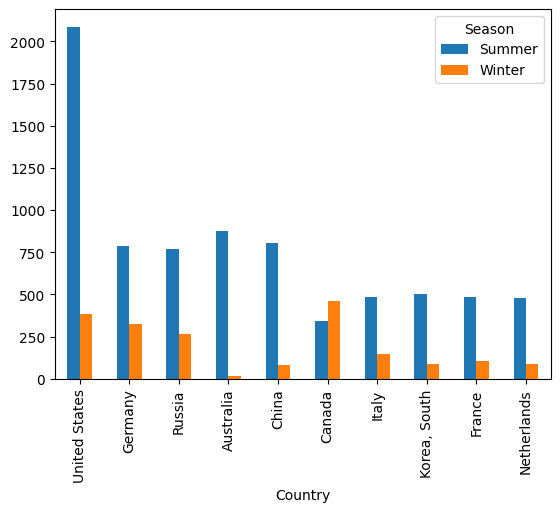

In [33]:
top_10_season_df[['Summer', 'Winter']].plot(kind="bar");

### Top 10 Countries event wins since 1984

In [34]:
all_df[(all_df.Year==2008) & (all_df.Event=='Basketball') & (all_df.Medal=='Gold')]


,Country,Code,Population,GDP per Capita,Year,City,Sport,Discipline,Athlete,Gender,Event,Medal,Season
25188,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"ANTHONY, Carmelo",Men,Basketball,Gold,Summer
25189,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"BOOZER, Carlos",Men,Basketball,Gold,Summer
25190,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"BOSH, Chris",Men,Basketball,Gold,Summer
25191,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"BRYANT, Kobe",Men,Basketball,Gold,Summer
25192,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"HOWARD, Dwight",Men,Basketball,Gold,Summer
25193,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"JAMES, Lebron",Men,Basketball,Gold,Summer
25194,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"KIDD, Jason",Men,Basketball,Gold,Summer
25195,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"PAUL, Chris",Men,Basketball,Gold,Summer
25196,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"PRINCE, Tayshaun",Men,Basketball,Gold,Summer
25197,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"REDD, Michael",Men,Basketball,Gold,Summer


In [35]:
all_df[(all_df.Year==2008) & (all_df.Event=='Basketball') & (all_df.Medal=='Gold')]

,Country,Code,Population,GDP per Capita,Year,City,Sport,Discipline,Athlete,Gender,Event,Medal,Season
25188,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"ANTHONY, Carmelo",Men,Basketball,Gold,Summer
25189,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"BOOZER, Carlos",Men,Basketball,Gold,Summer
25190,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"BOSH, Chris",Men,Basketball,Gold,Summer
25191,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"BRYANT, Kobe",Men,Basketball,Gold,Summer
25192,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"HOWARD, Dwight",Men,Basketball,Gold,Summer
25193,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"JAMES, Lebron",Men,Basketball,Gold,Summer
25194,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"KIDD, Jason",Men,Basketball,Gold,Summer
25195,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"PAUL, Chris",Men,Basketball,Gold,Summer
25196,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"PRINCE, Tayshaun",Men,Basketball,Gold,Summer
25197,United States,USA,321418820.0,56115.718426,2008,Beijing,Basketball,Basketball,"REDD, Michael",Men,Basketball,Gold,Summer


### To eliminate the duplication of team sports and calculate the top 10 countries by event victories since 1984:

In [36]:
# 1. Liquidation starting from 1984
since_1984 = all_df[all_df['Year'] >= 1984]

#2. Remove individual detail columns (Athlete, Gender) and then delete duplicates
cleaned_df = since_1984.drop(columns=['Athlete', 'Gender'], errors='ignore').drop_duplicates()

# 3. Top 10 Countries
top_10_events_df = (
    cleaned_df.groupby('Country')['Medal']
    .count()
    .sort_values(ascending=False)
    .head(10)
    .to_frame(name='Event Count')
)
top_10_events_df

,Event Count
Country,
United States,949
Germany,512
Russia,498
China,479
France,325
Italy,304
Australia,292
Canada,276
United Kingdom,271


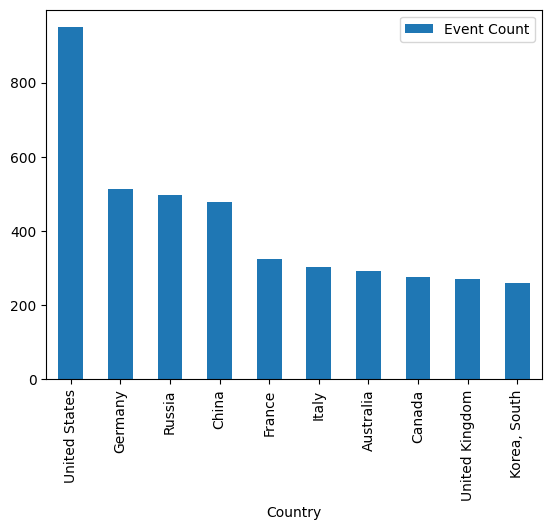

In [37]:
top_10_events_df.plot(kind='bar');

In [38]:
from nbresult import ChallengeResult

result = ChallengeResult('olympic_games_event',
    top_country_event_shape=top_10_events_df.shape,
    top_country_1_event=top_10_events_df.iloc[0]['Event Count'],
    top_country_10_event=top_10_events_df.iloc[9]['Event Count']
)
result.write()

print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/fatimah/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
rootdir: /home/fatimah/code/Fatima-23s/02-Data-Toolkit/01-Data-Analysis/data-multiple-files-with-pandas
configfile: pytest.ini
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 3 items

test_olympic_games_event.py::TestOlympicGamesEvent::test_top_10_events_shape PASSED [ 33%]
test_olympic_games_event.py::TestOlympicGamesEvent::test_top_events_1 PASSED [ 66%]
test_olympic_games_event.py::TestOlympicGamesEvent::test_top_events_10 PASSED [100%]

============================== 3 passed in 0.21s ===============================


💯 You can commit your code:

git add tests/olympic_games_event.pickle

git commit -m 'Completed olympic_games_event step'

git push origin master



### Optional - Merged results

In [40]:
top_10_df = since_1984.groupby('Country')['Medal'].count().sort_values(ascending=False).head(10).to_frame(name='Medal Count')

top_10_combined = top_10_events_df.merge(top_10_df, on='Country', how='outer')
top_10_combined = top_10_combined.sort_values(by='Medal Count', ascending=False)
top_10_combined

,Event Count,Medal Count
Country,,
United States,949.0,2472.0
Germany,512.0,1112.0
Russia,498.0,1031.0
Australia,292.0,891.0
China,479.0,889.0
Canada,276.0,801.0
Italy,304.0,632.0
France,325.0,587.0
"Korea, South",259.0,587.0


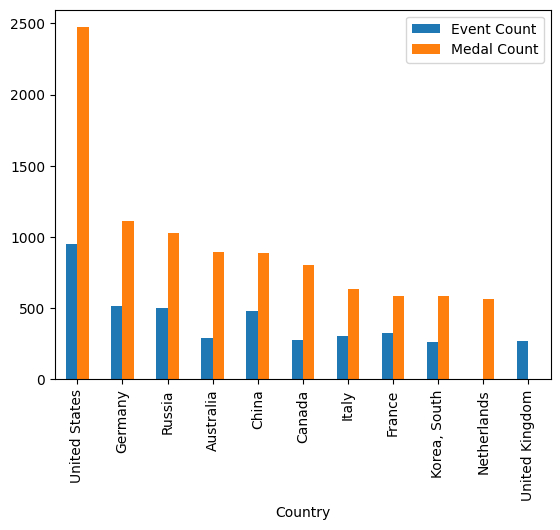

In [41]:
top_10_combined.plot(kind='bar');


In [42]:
from nbresult import ChallengeResult

result = ChallengeResult('olympic_games_combined',
    top_combined_shape=top_10_combined.shape,
    top_combined_1_event=top_10_combined.iloc[0]['Event Count'],
    top_combined_1_medal=top_10_combined.iloc[0]['Medal Count'],
    top_combined_10_event=top_10_combined.iloc[9]['Event Count'],
    top_combined_10_medal=top_10_combined.iloc[9]['Medal Count']
)
result.write()

print(result.check())



============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/fatimah/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
rootdir: /home/fatimah/code/Fatima-23s/02-Data-Toolkit/01-Data-Analysis/data-multiple-files-with-pandas
configfile: pytest.ini
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 3 items

test_olympic_games_combined.py::TestOlympicGamesCombined::test_combined_1 PASSED [ 33%]
test_olympic_games_combined.py::TestOlympicGamesCombined::test_combined_10 PASSED [ 66%]
test_olympic_games_combined.py::TestOlympicGamesCombined::test_top_10_combined_shape PASSED [100%]

============================== 3 passed in 0.10s ===============================


💯 You can commit your code:

git add tests/olympic_games_combined.pickle

git commit -m 'Completed olympic_games_combined step'

git push origin master

